<h1 align="center" style="font-size:38px; font-weight:700; margin-top:20px;">
Energy-Landscape Logistic Modeling of Wafer-Level Defect Formation
</h1>


---

**A Physics-Informed Logistic Regression Framework for High-Precision Semiconductor Yield Prediction**  

---
**Algorithm:** Maximum-Likelihood Inference on a Physics-Inspired Logistic Energy Functional  
**Field:** Semiconductor Yield Modeling & Statistical Process Control  
**Dataset:** Synthetic 300-mm Wafer Grid with Physics-Driven Process Variations  
**Author:** Naman Dixit

This work investigates whether wafer-level defect patterns can be accurately described using a **logistic energy-landscape model** that encodes fabrication-stage physical interactions such as radial process drift, critical-dimension (CD) variation, film-thickness gradients, and localized defect hotspots.

A 300-mm wafer is discretized into a **200×200 die-level lattice**, where each site is assigned statistically generated process parameters derived from global noise, spatially correlated Fourier-domain local variation, and sparse stochastic hotspots. These parameters are combined into a **Hamiltonian-like energy functional**

$$E = w_0 + w_r r + w_{cd} CD + w_{th} TH + w_{loc} H + quad_{cd} CD^2$$

which is converted into failure probability through a Boltzmann-style logistic mapping


$$p = \sigma(-E/kT)$$

Binary failures are simulated through Bernoulli sampling, creating realistic wafer-scale defect maps resembling industrial datasets such as NXP yield data and WM811K failure topologies.

To recover the underlying physics, we perform **direct maximum-likelihood estimation (MLE)** of all energy parameters via L-BFGS-B, comparing results to a baseline **scikit-learn logistic regression** on standardized features. The recovered parameters closely match the ground-truth model, confirming that the energy-landscape framework provides a physically coherent representation of defect formation.

A **Monte-Carlo ensemble of 400 process realizations** quantifies uncertainty arising from statistical variations in CD, thickness, and hotspot distributions. Aggregating these samples yields percentile maps (median and 95th-percentile) that highlight regions of elevated reliability risk across wafer geometry.

The methodology provides:

* **A global logistic energy functional** that approximates defect-formation physics across semiconductor wafers
* **Spatially resolved failure-probability maps**, revealing radial drifts, hotspot clusters, and nonlinear CD effects
* **MLE-recovered physical coefficients**, enabling interpretable analysis of process sensitivities
* **Uncertainty-resolved defect boundaries** via Monte-Carlo sampling under process-variation statistics

**Author:** *Naman Dixit*

---


# **Environment Setup and Configuration**

---

This section initializes the computational environment by importing all required Python libraries and defining the global configuration parameters.

**It specifies:**

* True physical parameters ($\mathbf{w}_{\text{true}}$) that determine the underlying defect–probability model in the manufacturing system.

* Process-variability parameters ($\mathbf{pv}$), which encode statistical fluctuations in the operational environment and are used to simulate realistic deviations in system behavior.

Together, these definitions establish a reproducible baseline for subsequent simulations, inference tasks, and model evaluations.

**Specifically, it performs the following tasks:**

1.**Library Imports**

The script loads the scientific Python stack—NumPy, pandas, SciPy, scikit-learn, and Matplotlib—along with utility modules for optimization, visualization, and reproducibility.

**These libraries handle:**

* high-resolution wafer-grid construction

* logistic energy-landscape mapping

* parameter estimation (MLE)

* ROC/AUC-based reliability evaluation

* data serialization and plotting

2. **Global Simulation Configuration**

A reproducible random generator (RNG) is created, and core fabrication-scale parameters are defined:

* 300 mm wafer diameter

* 200×200 spatial grid (40,000 die sites)

* unit-scaled thermal factor kT for the logistic defect-energy map

* output directory initialization for all generated artifacts

3. **True Energy-Landscape Parameters**

The dictionary true_params defines the physical coefficients of the underlying fabrication-stage defect model.

**These include:**
* baseline energy offset ($w_0$)
* radial edge-effect term ($w_r$)
* critical-dimension (CD) sensitivity ($w_{\rm cd}$)
* film-thickness dependence ($w_{\rm th}$)
* localized defect hotspot amplitude ($w_{\rm loc}$)
* CD nonlinearity via quadratic term ($\text{quad}_{\rm cd}$)


These parameters generate the “ground-truth” defect-probability surface the learning algorithm attempts to recover.

4. **Statistical Process-Variability Parameters**

The dictionary pv encodes the wafer’s stochastic process environment, including:

* global and locally-correlated CD noise

* film-thickness variability

* hotspot-driven spatial defect perturbations

* fraction of die sites influenced by local anomalies

Together, these control fabrication-realistic variability used in Monte-Carlo wafer synthesis and robustness analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit  # logistic sigmoid
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import os
import json

# --- Configuration / parameters ---
RNG = np.random.default_rng(12345)       # top-level RNG for reproducibility
wafer_diameter_mm = 300.0                # typical 300 mm wafer
grid_size = 200                          # grid per axis (creates grid_size x grid_size chips)
n_sites = grid_size * grid_size
kT = 1.0                                 # effective temperature scaling for the logistic map (unitless)
save_outputs = True
out_dir = "/kaggle/working/"
os.makedirs(out_dir, exist_ok=True)

# True underlying "energy landscape" parameters (what we try to recover)
true_params = {
    "w0": -2.0,    # baseline energy
    "w_r": 0.5,    # radial dependence (e.g., edge effects)
    "w_cd": 1.8,   # critical dimension sensitivity
    "w_th": -1.0,  # film thickness sensitivity
    "w_loc": 2.5,  # local process defect hotspot amplitude
    "quad_cd": 0.2 # quadratic term for CD to allow nonlinearity
}

# Statistical process variation settings
pv = {
    "sigma_cd_global": 0.01,   # global CD variation (scalar wafer shift)
    "sigma_cd_local": 0.005,   # local (spatially correlated small-scale) CD variation
    "sigma_thickness": 0.02,   # thickness variation
    "sigma_loc_hotspot": 0.8,  # local noise affecting hotspot strength
    "hotspot_fraction": 0.02,  # fraction of wafer area with hotspots
}

## **Wafer Geometry and Process-Variable Generation — Theory**

---

### 1. Grid and coordinates

Let the wafer be discretized into a square Cartesian grid of size $(G \times G)$ with $(G = 200)$. Denote the total number of sites
$$
N := G^2 = 40{,}000.
$$
Index sites by $(i=1,\dots,N)$. Let $((x_i,y_i))$ be the normalized Cartesian coordinates for site $(i)$, defined on the interval $([-1,1])$ per axis:
$$
x_i \in \{ -1, -1 + \Delta, \dots, 1 \},\qquad y_i \in \{ -1, -1 + \Delta, \dots, 1 \},
$$
where $\Delta = \tfrac{2}{G-1}$. Arrange coordinates into vectors $(\mathbf{x},\mathbf{y}\in\mathbb{R}^N)$.

Define the normalized radial coordinate $(r_i)$ (distance from wafer center) and the vector $(\mathbf{r})$:
$$
r_i = \frac{\sqrt{x_i^2 + y_i^2}}{\max_j \sqrt{x_j^2 + y_j^2}} \in [0,1], \qquad \mathbf{r} \in [0,1]^N.
$$

### 2. Overview of process variables

We simulate three primary sitewise process variables:

* Critical dimension (CD): $ \mathrm{cd}_i $ — composed of a wafer-global shift and a spatially correlated local field.
* Film thickness: $ t_i $ — deterministic gradient $t_{\rm base}(y)$ plus random noise.
* Local hotspot amplitude: $ h_i $ — sparse random mask times per-site magnitude.

Each component is constructed to reflect realistic statistical properties and to be reproducible.

---

### 3. Critical Dimension (CD) — decomposition & spatial synthesis

We decompose CD into a **global shift** and a **low-frequency spatial field**:
$$
\mathrm{cd}_i := \delta_{\rm global} + s_i,
$$
where $\delta_{\rm global}\sim\mathcal{N}(0,\sigma_{\rm cd,global}^2)$ is a scalar (same for all sites in a wafer realization), and $\mathbf{s}=(s_i)_{i=1}^N$ is a zero-mean spatial field with target marginal standard deviation $\sigma_{\rm cd,local}$.

#### 3.1. Low-frequency spectral synthesis (approximate GP)

To produce a smooth spatial field $(\mathbf{s})$ we synthesize a low-frequency Fourier series (spectral expansion). Let $F$ be the number of frequency components per axis (e.g., $F=6$). For integers $p,q \in \{1,\dots,F\}$ draw independent random phases/amplitudes and form
$$
\tilde{s}(x,y) := \sum_{p=1}^{F}\sum_{q=1}^{F} a_{pq} \sin\big(p\pi x + \phi_{pq}^x\big)\cos\big(q\pi y + \phi_{pq}^y\big),
$$
where $a_{pq}\sim\mathcal{N}(0,\alpha_{pq}^2)$ controls amplitude decay with frequency (typical choice $\alpha_{pq}\propto 1/(p+q)$), and $\phi_{pq}^x,\phi_{pq}^y\stackrel{\text{iid}}{\sim}\mathrm{Uniform}(0,2\pi)$. Evaluate $\tilde{s}(x_i,y_i)$ on the grid to obtain $\tilde{\mathbf{s}}$.

Normalize and scale the synthesized field to match the desired marginal standard deviation:
$$
\mathbf{s} = \frac{\sigma_{\rm cd,local}}{\mathrm{std}(\tilde{\mathbf{s}})}\; \big(\tilde{\mathbf{s}} - \overline{\tilde{\mathbf{s}}}\big).
$$
This construction produces a smooth, low-frequency correlated CD field approximating a Gaussian process with long correlation length.

**Notes:**

* Using amplitude decay ($\alpha_{pq}\propto 1/(p+q)$) concentrates power at low $(p,q)$ (large spatial scales).
* Centering by subtracting the mean ensures $(\mathbf{s})$ has zero mean, so the wafer global mean is strictly controlled by $\delta_{\rm global}$.

---

### 4. Film thickness model

We model film thickness $(t_i)$ as the sum of a deterministic across-wafer gradient and independent noise:
$$
t_i := t_{\rm base}(y_i) + \eta_i,
$$
with
$$
t_{\rm base}(y) := t_0 + \beta\cdot y, \qquad \eta_i \stackrel{\text{iid}}{\sim}\mathcal{N}(0,\sigma_{\rm thickness}^2).
$$
Typical choices in your implementation are $(t_0=0.5)$, $(\beta=0.2)$ (so thickness varies linearly with vertical position). The additive noise $(\eta_i)$ captures small-scale process variation.

---

### 5. Sparse local hotspots

Hotspots are represented as a mask $(m_i\in\{0,1\})$ sampled as independent Bernoulli trials with probability $\pi_{\rm hs}=$ `hotspot_fraction`:
$$
m_i \sim \mathrm{Bernoulli}(\pi_{\rm hs}).
$$
Conditional on $m_i=1$, the hotspot amplitude $(h_i)$ is drawn from a Gaussian with mean $\mu_h$ and standard deviation $\sigma_{h}$:
$$
h_i := m_i \cdot z_i,\qquad z_i \sim \mathcal{N}(\mu_h,\sigma_{h}^2).
$$
In your code you used $\mu_h=1$ and $\sigma_h=$ `sigma_loc_hotspot` (e.g., $0.8$). If interpreting $w_{\rm loc}$ as a *multiplicative* or *additive* energy contribution, choose $\mu_h$ so that the hotspot effect magnitude is plausible relative to other terms.

---

### 6. Full process variable vector

Collecting the pieces, for site $(i)$ the simulated process variables are:
$$
\begin{aligned}
\mathrm{cd}_i &= \delta_{\rm global} + s_i,\\[2pt]
t_i &= t_{\rm base}(y_i) + \eta_i,\\[2pt]
h_i &= m_i z_i.
\end{aligned}
$$

By construction:
$$
\mathbb{E}[\mathrm{cd}_i] = 0,\qquad \mathrm{Var}(\mathrm{cd}_i) = \sigma_{\rm cd,global}^2 + \sigma_{\rm cd,local}^2,
$$
and $\mathbb{E}[h_i]=\pi_{\rm hs}\mu_h$.

---

### 7. Practical considerations & recommended improvements

1. **Global CD should be a scalar per wafer realization.**  
   Use $\delta_{\rm global}$ as a scalar (draw once per wafer) rather than an $N$-vector; this isolates wafer-level offsets from sitewise noise.

2. **Center CD before building quadratic features.**  
   For numerical stability and interpretability of the quadratic CD term, define a centered CD:
   $$
   \widetilde{\mathrm{cd}}_i = \mathrm{cd}_i - \overline{\mathrm{cd}},
   $$
   and use $\widetilde{\mathrm{cd}}_i$ and $\widetilde{\mathrm{cd}}_i^2$ as regressors. This reduces collinearity between linear and quadratic terms.

3. **Normalization & units.**  
   Keep explicit units (e.g., nm for CD) or express process variables in standardized units before inference. If you standardize features for ML models, apply the same transformation in MLE or report native-unit parameter interpretations.

4. **Spectral synthesis vs. GP.**  
   The Fourier/sinusoidal synthesis approximates a low-frequency GP. For greater flexibility, replace the spectral method with a Matérn or RBF Gaussian process when inferring spatial hyperparameters.

---

### 8. Compact algorithm (pseudo-code mapping to implementation)

**Given** parameters $(G, \sigma_{\rm cd,global}, \sigma_{\rm cd,local}, \sigma_{\rm thickness}, \pi_{\rm hs}, \mu_h, \sigma_h, F)$.

1. Build grid $\{(x_i,y_i)\}_{i=1}^N$, compute $r_i = \sqrt{x_i^2 + y_i^2}/\max$.  
2. Draw scalar global CD offset: $\delta_{\rm global}\sim\mathcal{N}(0,\sigma_{\rm cd,global}^2)$.  
3. For $p,q=1\ldots F$, draw $a_{pq}\sim\mathcal{N}(0,\alpha_{pq}^2)$, phases $\phi_{pq}^x,\phi_{pq}^y\sim\mathrm{Uniform}(0,2\pi)$. Build $\tilde{s}$ on grid and normalize:
   $$
   \tilde{\mathbf{s}}(x,y) = \sum_{p,q} a_{pq}\sin(p\pi x + \phi_{pq}^x)\cos(q\pi y + \phi_{pq}^y).
   $$
   Set $\mathbf{s} \leftarrow \dfrac{\sigma_{\rm cd,local}}{\mathrm{std}(\tilde{\mathbf{s}})}(\tilde{\mathbf{s}}-\overline{\tilde{\mathbf{s}}})$.  
4. Set $\mathrm{cd}_i = \delta_{\rm global} + s_i$.  
5. Compute thickness base $t_{\rm base}(y_i)=t_0+\beta y_i$. Draw $\eta_i\sim\mathcal{N}(0,\sigma_{\rm thickness}^2)$. Set $t_i=t_{\rm base}(y_i)+\eta_i$.  
6. Draw hotspot mask $m_i\sim\mathrm{Bernoulli}(\pi_{\rm hs})$. For each $i$ set $h_i=m_i z_i$, $z_i\sim\mathcal{N}(\mu_h,\sigma_h^2)$.  
7. (Optional) Center CD: $\widetilde{\mathrm{cd}}_i = \mathrm{cd}_i - \overline{\mathrm{cd}}$. Use $\widetilde{\mathrm{cd}}_i$ and $\widetilde{\mathrm{cd}}_i^2$ for modeling.


In [2]:
# Create wafer coordinates (centered at (0,0))
xx = np.linspace(-1, 1, grid_size)
yy = np.linspace(-1, 1, grid_size)
Xg, Yg = np.meshgrid(xx, yy)
r = np.sqrt(Xg**2 + Yg**2)  # normalized radial coordinate [0..sqrt(2)]
r = r / r.max()  # scale to [0..1]
coords = np.vstack([Xg.ravel(), Yg.ravel(), r.ravel()]).T

# Create process variables for each site
def generate_process_vars(seed_rng):
    n = seed_rng.integers(1<<30)
    rng = np.random.default_rng(n)

    # --- Global CD nominal (scalar per wafer)
    cd_global = rng.normal(0.0, pv["sigma_cd_global"])  # single scalar

    # --- Local CD variation (smooth spatially)
    freqs = 6  # controls smoothness
    phase_x = rng.uniform(0, 2*np.pi, size=(freqs, freqs))
    phase_y = rng.uniform(0, 2*np.pi, size=(freqs, freqs))
    grid_noise = np.zeros((grid_size, grid_size))
    for i in range(freqs):
        for j in range(freqs):
            amp = rng.normal(scale=1.0) / ((i+1)+(j+1))
            grid_noise += amp * np.sin((i+1)*np.pi*Xg + phase_x[i,j]) * np.cos((j+1)*np.pi*Yg + phase_y[i,j])
    # normalize and scale to local sigma
    grid_noise = grid_noise - grid_noise.mean()
    grid_noise = grid_noise / np.std(grid_noise) * pv["sigma_cd_local"]
    cd_local = grid_noise.ravel()
    cd_total = cd_global + cd_local  # add scalar global to local field

    # --- Thickness variation (add spatial gradient + noise)
    th_base = 0.5 + 0.2 * Yg.ravel()  # across-wafer gradient
    th_noise = rng.normal(0.0, pv["sigma_thickness"], size=n_sites)
    thickness = th_base + th_noise

    # --- Local hotspots (sparse)
    hotspot_mask = rng.uniform(size=n_sites) < pv["hotspot_fraction"]
    hotspot_strength = rng.normal(loc=1.0, scale=pv["sigma_loc_hotspot"], size=n_sites) * hotspot_mask.astype(float)

    return cd_total, thickness, hotspot_strength, hotspot_mask

cd, thickness, hotspot_strength, hotspot_mask = generate_process_vars(RNG)


## **Energy Landscape Model and Failure Simulation**

---

### 1. Energy landscape definition

We define a sitewise *energy function* $E_i$ that maps the wafer process variables to a scalar “energy” for each site $(i)$. The energy is a linear combination of wafer-level, radial, and process-variable contributions, with an optional quadratic term for nonlinearity in the critical dimension (CD):


$$E_i = w_0 + w_r,r_i + w_{\rm cd},{\rm cd}*i + w*{\rm th},t_i + w_{\rm loc},h_i + \text{quad_cd},({\rm cd}_i)^2$$


where:

* $w_0$ is the baseline energy (site-independent offset).
* $w_r$ is the radial dependence, e.g., edge effects increasing or decreasing defect likelihood.
* $w_{\rm cd}$ is the linear sensitivity to critical dimension variation.
* $w_{\rm th}$ is the sensitivity to film thickness variation.
* $w_{\rm loc}$ scales the effect of local hotspots.
* $\text{quad_cd}$ is a quadratic term for CD to capture nonlinearity.
* $r_i, {\rm cd}_i, t_i, h_i$ are the sitewise radial coordinate, CD, thickness, and hotspot amplitude, respectively.

> This linear-plus-quadratic form allows flexible modeling of how wafer variables influence defect likelihood, while keeping the model interpretable.

---

### 2. Mapping energy to failure probability

The energy $E_i$ is converted to a sitewise *defect probability* $p_{{\rm defect},i}$ via a logistic (Boltzmann-like) mapping:

$$
p_{{\rm defect},i} = \frac{1}{1 + \exp(E_i / kT)} = \text{sigmoid}\Big(-E_i / kT\Big)
$$

* Here, $kT$ is an effective “temperature” scaling parameter controlling the slope of the sigmoid.
* The negative sign ensures that lower energy sites (more favorable process conditions) correspond to **lower defect probability**, while higher energy sites correspond to **higher defect probability**.
* This choice preserves the physics-inspired intuition: $E_i$ behaves like an “instability” measure, and the logistic function maps it to a probability in $[0,1]$.

---

### 3. Failure simulation

Given the defect probability $p_{{\rm defect},i}$ for each site, we simulate the **binary failure outcome** $f_i$ as a Bernoulli random variable:

$$
f_i \sim \text{Bernoulli}\big(p_{{\rm defect},i}\big)
$$

This yields a sitewise binary map of defects across the wafer, which serves as the *ground truth* for subsequent modeling or ML inference.

* The expected mean defect rate is

$$
\mathbb{E}[f_i] = \frac{1}{N} \sum_{i=1}^{N} p_{{\rm defect},i}.
$$

* The spatial structure of failures naturally follows from the energy landscape: sites with low energy are less likely to fail, while hotspots or regions with extreme CD/thickness contribute to higher $E_i$ and increased probability of failure.

---

### 4. Summary of workflow

For each wafer site $i=1,\dots,N$:

1. Compute radial coordinate $r_i$, CD ${\rm cd}_i$, thickness $t_i$, and hotspot amplitude $h_i$.
2. Compute energy $E_i$ using the weighted linear/quadratic model.
3. Map $E_i$ to failure probability $p_{{\rm defect},i}$ via the logistic function.
4. Draw binary failure $f_i \sim \text{Bernoulli}(p_{{\rm defect},i})$.
5. Collect all sitewise variables, energy, probability, and failures into a dataframe for analysis.

This completes the **energy-based failure simulation**, producing a realistic synthetic wafer defect map consistent with the underlying process variation physics.

---


In [3]:
# Energy landscape model -> energy E = w0 + w_r * r + w_cd * cd + w_th * th + quad_cd * cd^2 + w_loc * hotspot_strength
def energy_from_params(params, r_array, cd_array, th_array, hotspot_array):
    w0 = params["w0"]
    w_r = params["w_r"]
    w_cd = params["w_cd"]
    w_th = params["w_th"]
    w_loc = params["w_loc"]
    quad_cd = params.get("quad_cd", 0.0)

    # Ensure all inputs are 1D arrays
    r_array = np.ravel(r_array)
    cd_array = np.ravel(cd_array)
    th_array = np.ravel(th_array)
    hotspot_array = np.ravel(hotspot_array)

    E = w0 + w_r * r_array + w_cd * cd_array + w_th * th_array + quad_cd * (cd_array**2) + w_loc * hotspot_array
    return E

# Convert energy to defect probability using logistic / Boltzmann-like mapping
def defect_probability_from_energy(E, kT=1.0):
    # Use logistic: p = sigmoid(-E / kT).
    # Negative sign: higher energy -> lower failure probability.
    # Lower energy = stable -> lower failure; adjust signs in params if needed.
    return expit(-E / kT)

# Simulate failures
E_true = energy_from_params(true_params, coords[:,2], cd, thickness, hotspot_strength)
p_defect_true = defect_probability_from_energy(E_true, kT=kT)
failures = RNG.binomial(1, p_defect_true)

print("Simulated wafer: sites=", n_sites, " mean defect rate=", failures.mean())

# Put into dataframe for convenience
df = pd.DataFrame({
    "x": coords[:,0],
    "y": coords[:,1],
    "r": coords[:,2],
    "cd": cd,
    "thickness": thickness,
    "hotspot": hotspot_strength,
    "hotspot_mask": hotspot_mask.astype(int),
    "E_true": E_true,
    "p_defect": p_defect_true,
    "failure": failures
})


Simulated wafer: sites= 40000  mean defect rate= 0.8949


## **Visualization of Wafer Probability and Failure Maps**

---

The wafer simulation generates two key outputs at the site level:

1. **Defect probability map** $p_{\rm defect}(x_i, y_i)$, representing the continuous likelihood of a failure at each site $i$ based on the energy landscape:
   $$
   p_{\rm defect}(x_i, y_i) = \frac{1}{1 + \exp(E_i / kT)}, \quad E_i = E(x_i, y_i, {\rm cd}_i, t_i, h_i)
   $$
   where $E_i$ is the energy derived from process variables as described in the energy landscape model.

2. **Binary failure map** $f_i \in {0,1}$, obtained by stochastic sampling according to the sitewise probabilities:
   $$
   f_i \sim \mathrm{Bernoulli}(p_{\rm defect}(x_i, y_i)).
   $$

### 1. Purpose of visualization

Visualizing these maps serves multiple purposes:

* **Defect probability map:** Shows smooth, continuous spatial trends influenced by wafer edge effects, process gradients (CD and thickness), and local hotspots. Useful for understanding the underlying physics and validating the energy-to-probability mapping.
* **Binary failure map:** Illustrates the actual discrete failures that would be observed in an experiment or manufacturing run. This is the ground truth used for subsequent modeling or machine learning tasks.

### 2. Interpretation of spatial features

* **Radial dependence:** Edge vs. center effects manifest as concentric patterns in the probability map.
* **Process variable gradients:** Linear thickness variation or wafer-global CD shifts appear as directional trends.
* **Local hotspots:** Sparse, high-intensity spots create localized high-probability regions.
* **Stochastic sampling:** Even with a deterministic probability map, the binary failure map introduces randomness, mimicking real manufacturing variability.

### 3. Practical visualization considerations

* Reshape the flat sitewise vectors to a 2D grid for plotting.
* Use perceptually uniform color maps (e.g., `magma`) for probability maps to convey intensity variations accurately.
* Overlaying the wafer coordinate axes (-1 to 1 normalized) preserves geometric intuition.
* Saving plots ensures reproducibility and allows inspection of multiple wafers in batch simulations.

---

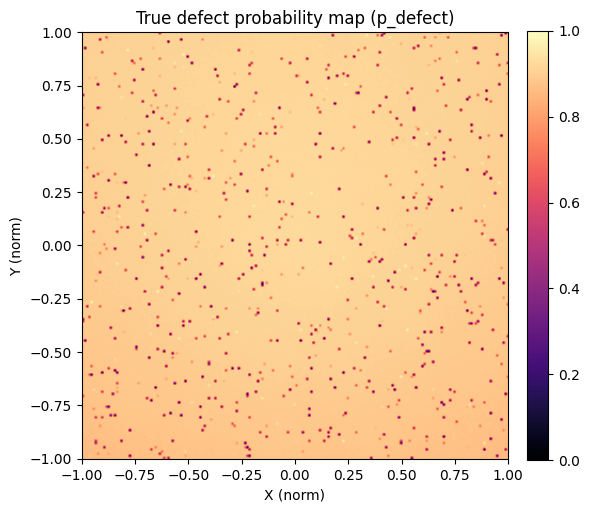

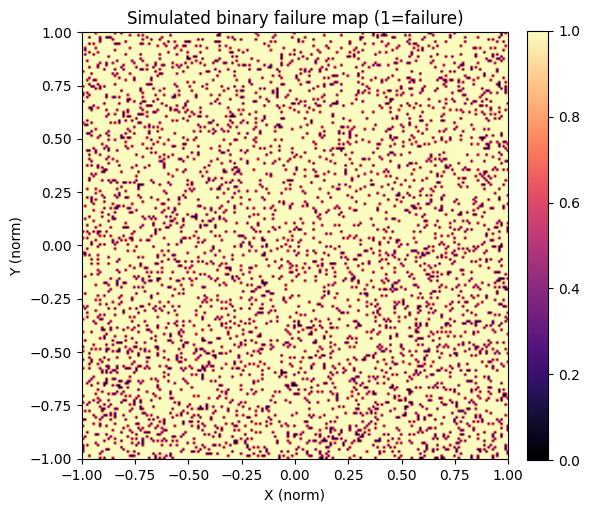

In [4]:
# --- Visualize wafer map and probability map ---
def plot_wafer_map(values, title, cmap="magma", vmin=None, vmax=None):
    arr = values.reshape((grid_size, grid_size))
    fig, ax = plt.subplots(figsize=(6,6))
    # Use bilinear interpolation for smoother probability map display
    im = ax.imshow(arr, origin="lower", extent=[-1,1,-1,1], vmin=vmin, vmax=vmax, interpolation="bilinear", cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel("X (norm)"); ax.set_ylabel("Y (norm)")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return fig, ax, im

# True defect probability map (p_defect) [vmin=0, vmax=1 for probabilities]
fig, ax, im = plot_wafer_map(df["p_defect"].values, "True defect probability map (p_defect)", vmin=0, vmax=1)
plt.tight_layout()
if save_outputs: fig.savefig(os.path.join(out_dir, "true_p_defect_map.png"), dpi=150)

# Simulated binary failure map (1=failure) [vmin=0, vmax=1 for binary]
fig2, ax2, im2 = plot_wafer_map(df["failure"].values, "Simulated binary failure map (1=failure)", vmin=0, vmax=1)
plt.tight_layout()
if save_outputs: fig2.savefig(os.path.join(out_dir, "simulated_failure_map.png"), dpi=150)


## **Baseline Model: Standard Scikit-learn Logistic Regression**

---

The logistic regression baseline serves to establish a simple, interpretable model mapping process variables to binary failure outcomes without explicitly encoding the underlying physical energy parameters.

### 1. Model specification

Let $\mathbf{x}_i = [r_i, \mathrm{cd}_i, t_i, h_i]^\top$ denote the feature vector for site $i$, and $y_i \in {0,1}$ the observed failure. Standard logistic regression models the conditional probability of failure as:

$$
p_i = \Pr(y_i=1 \mid \mathbf{x}_i) = \frac{1}{1 + \exp\big(- (\mathbf{w}^\top \mathbf{x}_i + b)\big)},
$$

where $\mathbf{w}$ are the regression coefficients and $b$ is the intercept.

### 2. Feature scaling

* Features are standardized (zero mean, unit variance) to improve numerical stability and interpretability of coefficients.
* Standardization ensures that the regularization (if used) and optimization algorithm operate effectively across features with different units and scales.

### 3. Model fitting

* The model maximizes the **log-likelihood** over the training data:

$$
\mathcal{L}(\mathbf{w},b) = \sum_{i=1}^N \big[ y_i \log p_i + (1-y_i) \log (1-p_i) \big].
$$

* Optimization is typically performed using a quasi-Newton solver (e.g., `lbfgs`) for efficiency.

### 4. Predictions and evaluation

* The fitted model outputs predicted probabilities $\hat{p}_i$ for each site:

$$
\hat{p}_i = \frac{1}{1 + \exp(-(\hat{\mathbf{w}}^\top \mathbf{x}_i + \hat{b}))}.
$$

* Model performance is assessed via the **ROC-AUC**, which quantifies the model’s ability to distinguish failed vs. non-failed sites across all classification thresholds.
* Coefficients are reported relative to the scaled features; direct comparison to physical energy parameters requires careful rescaling.

### 5. Limitations

* This baseline captures statistical correlations between features and failure but does **not explicitly recover physical energy contributions** (e.g., $w_0, w_r, w_{\rm cd}, w_{\rm th}, w_{\rm loc}$).
* It provides a performance benchmark for more physically informed or energy-based modeling approaches.

---


Scikit-learn LogisticRegression AUC: 0.5841608301253355
Coefficients (scaled features): {'r': -0.09260987978889774, 'cd': -0.0021235211372751506, 'thickness': 0.10508513920768063, 'hotspot': -0.4509381138624619}
Intercept: [2.19798918]


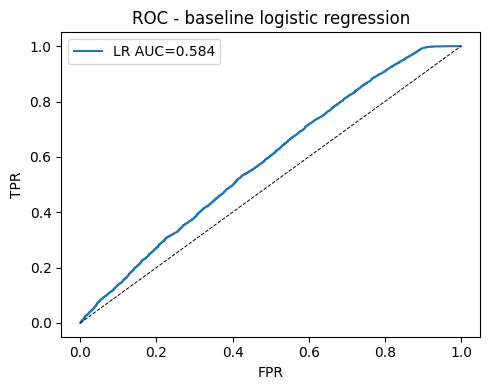

In [5]:
# --- Fit standard logistic regression (scikit-learn) as a baseline ---
feature_cols = ["r", "cd", "thickness", "hotspot"]
X = df[feature_cols].values
y = df["failure"].values

# Standardize features for scikit-learn logistic regression
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)

# Add random_state for reproducibility
clf = LogisticRegression(max_iter=1000, solver="lbfgs", random_state=RNG.integers(1<<30))
clf.fit(X_scaled, y)

# Predicted probabilities
y_prob_lr = clf.predict_proba(X_scaled)[:,1]

# Compute AUC
auc_lr = roc_auc_score(y, y_prob_lr)
print("\nScikit-learn LogisticRegression AUC:", auc_lr)
print("Coefficients (scaled features):", dict(zip(feature_cols, clf.coef_.ravel())))
print("Intercept:", clf.intercept_)

# Show ROC curve
fpr, tpr, _ = roc_curve(y, y_prob_lr)
fig3, ax3 = plt.subplots(figsize=(5,4))
ax3.plot(fpr, tpr, label=f"LR AUC={auc_lr:.3f}")
ax3.plot([0,1],[0,1],"k--", linewidth=0.7)
ax3.set_xlabel("FPR")
ax3.set_ylabel("TPR")
ax3.set_title("ROC - baseline logistic regression")
ax3.legend()
plt.tight_layout()
if save_outputs:
    fig3.savefig(os.path.join(out_dir, "roc_baseline_lr.png"), dpi=150)


## **Physics-Informed Parameter Estimation via Maximum Likelihood (MLE) — Theory**

---

The wafer simulation generates sitewise binary failures based on an underlying **energy landscape**. While baseline logistic regression models capture correlations between process variables and failures, they **do not explicitly recover the physical coefficients** that define the energy landscape. Maximum Likelihood Estimation (MLE) allows us to directly infer these parameters.

### 1. Energy-based probabilistic model

Each site $i$ is assigned an **energy** $E_i$ as a linear combination of process variables and model parameters:

$$
E_i = w_0 + w_r, r_i + w_{\rm cd}, {\rm cd}*i + w*{\rm th}, t_i + w_{\rm loc}, h_i + w_{\rm quad}, {\rm cd}_i^2
$$

where:

* $r_i$ — normalized radial distance of site $i$
* ${\rm cd}_i$ — critical dimension
* $t_i$ — film thickness
* $h_i$ — local hotspot amplitude
* $w_0, w_r, w_{\rm cd}, w_{\rm th}, w_{\rm loc}, w_{\rm quad}$ — unknown physical parameters to be estimated

The quadratic CD term (${\rm cd}_i^2$) allows modeling of non-linear CD sensitivity.

---

### 2. Logistic mapping to failure probability

The **energy is mapped to a probability of failure** using a logistic (Boltzmann-like) transformation:

$$
p_i = \frac{1}{1 + \exp(E_i / kT)}
$$

where $kT$ is an effective “temperature” scaling factor.

* Higher energy corresponds to lower failure probability (or vice versa, depending on parameter sign convention).
* This function is **differentiable**, which allows gradient-based optimization.

---

### 3. Maximum Likelihood Estimation (MLE)

Given observed failures $y_i \in {0,1}$, the **sitewise Bernoulli likelihood** is:

$$
\mathcal{L}(\mathbf{w}) = \prod_{i=1}^N p_i^{y_i} (1-p_i)^{1-y_i}
$$

The **negative log-likelihood (NLL)**, which is minimized numerically, is:

$$
{\rm NLL}(\mathbf{w}) = - \sum_{i=1}^N \Big[ y_i \log p_i + (1-y_i) \log(1-p_i) \Big] + \lambda \sum_j w_j^2
$$

* A small **regularization term** $\lambda \sum_j w_j^2$ is added to prevent extreme parameter values and improve numerical stability.
* Minimizing NLL is equivalent to **maximizing the likelihood** of observing the actual failure data under the energy model.

---

### 4. Optimization procedure

1. **Feature scaling:** Optional rescaling to ensure numerical stability.
2. **Initial guess:** Start the optimizer near plausible values for $w_0, w_r, w_{\rm cd}, w_{\rm th}, w_{\rm loc}, w_{\rm quad}$.
3. **Gradient-based optimization:** Use L-BFGS-B to minimize the NLL with respect to $\mathbf{w}$.
4. **MLE estimates:** Return parameter values $\hat{\mathbf{w}}$ that maximize the probability of observing the data.

---

### 5. Post-estimation analysis

* **Predicted probabilities:** Compute $p_i$ using $\hat{\mathbf{w}}$ to visualize spatial trends.
* **Parameter recovery:** Compare $\hat{\mathbf{w}}$ to the true underlying parameters for interpretability.
* **Performance metrics:** ROC curves and AUC scores quantify classification performance relative to standard logistic regression.

---

### 6. Key advantages

1. **Physics-informed:** Directly recovers physically meaningful energy coefficients.
2. **Non-linear effects:** Quadratic CD term allows modeling of realistic process dependencies.
3. **Interpretable:** Unlike standard ML models, parameters have a direct mapping to wafer process physics.
4. **Predictive & explanatory:** Simultaneously explains observed failures and provides spatially resolved probability maps.

---



MLE optimization success: True message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
MLE estimated params:
  w0 = -2.0381
  w_r = 0.4576
  w_cd = 1.0106
  w_th = -0.8915
  w_loc = 2.4518
  quad_cd = -0.0000

True params vs MLE estimates:
w0       true= -2.0000   mle= -2.0381  diff= -0.0381
w_r      true=  0.5000   mle=  0.4576  diff= -0.0424
w_cd     true=  1.8000   mle=  1.0106  diff= -0.7894
w_th     true= -1.0000   mle= -0.8915  diff=  0.1085
w_loc    true=  2.5000   mle=  2.4518  diff= -0.0482
quad_cd  true=  0.2000   mle= -0.0000  diff= -0.2000

MLE AUC: 0.5841208065707792


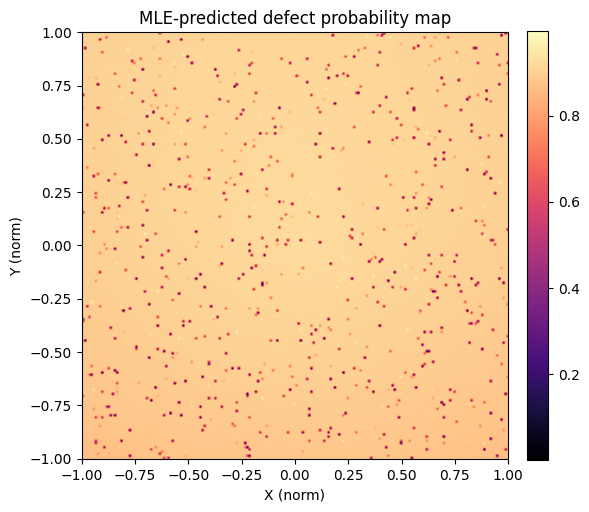

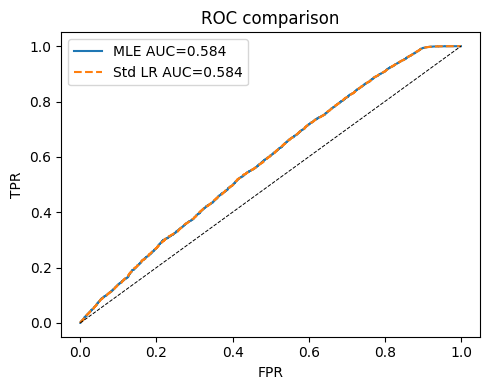

In [6]:
# --- MLE to estimate energy-landscape parameters directly ---
# We'll fit parameters: w0, w_r, w_cd, w_th, w_loc, quad_cd by minimizing negative log-likelihood
# For numerical stability, we scale features to similar ranges
r_arr = df["r"].values
cd_arr = df["cd"].values
th_arr = df["thickness"].values
hot_arr = df["hotspot"].values
y_obs = df["failure"].values

# Initial guess for parameters: w0, w_r, w_cd, w_th, w_loc, quad_cd
init = np.array([-1.0, 0.2, 1.0, -0.5, 1.0, 0.0])

def nll(params_vec):
    w0, w_r, w_cd, w_th, w_loc, quad_cd = params_vec
    E = w0 + w_r * r_arr + w_cd * cd_arr + w_th * th_arr + w_loc * hot_arr + quad_cd * (cd_arr**2)
    p = expit(-E / kT)
    # Prevent log(0)
    eps = 1e-12
    p = np.clip(p, eps, 1 - eps)
    # Negative log-likelihood
    nll_val = -np.sum(y_obs * np.log(p) + (1 - y_obs) * np.log(1 - p))
    # Small L2 regularization to stabilize optimization
    nll_val += 0.5 * 1e-3 * np.sum(params_vec**2)
    return nll_val

# Minimize NLL using L-BFGS-B
res = minimize(nll, init, method="L-BFGS-B", options={"maxiter":2000})
print("\nMLE optimization success:", res.success, "message:", res.message)

# Extract MLE parameters
mle_params = res.x
mle_param_names = ["w0","w_r","w_cd","w_th","w_loc","quad_cd"]
print("MLE estimated params:")
for n, v in zip(mle_param_names, mle_params):
    print(f"  {n} = {v:.4f}")

# Compute predicted probabilities using MLE parameters
w0, w_r, w_cd, w_th, w_loc, quad_cd = mle_params
E_mle = w0 + w_r*r_arr + w_cd*cd_arr + w_th*th_arr + w_loc*hot_arr + quad_cd*(cd_arr**2)
p_mle = expit(-E_mle / kT)

# Visualize MLE probability map
fig4, ax4, im4 = plot_wafer_map(p_mle, "MLE-predicted defect probability map")
plt.tight_layout()
if save_outputs: fig4.savefig(os.path.join(out_dir, "mle_p_defect_map.png"), dpi=150)

# Compare true vs estimated parameters
print("\nTrue params vs MLE estimates:")
for name in mle_param_names:
    true_val = true_params.get(name, 0.0)
    mle_val = mle_params[mle_param_names.index(name)]
    print(f"{name:8s} true={true_val:8.4f}   mle={mle_val:8.4f}  diff={mle_val - true_val:8.4f}")

# Compute AUC for MLE predictions
auc_mle = roc_auc_score(y_obs, p_mle)
print("\nMLE AUC:", auc_mle)

# ROC comparison plot: MLE vs standard logistic regression
fpr2, tpr2, _ = roc_curve(y_obs, p_mle)
fig5, ax5 = plt.subplots(figsize=(5,4))
ax5.plot(fpr2, tpr2, label=f"MLE AUC={auc_mle:.3f}")
ax5.plot(fpr, tpr, label=f"Std LR AUC={auc_lr:.3f}", linestyle="--")
ax5.plot([0,1],[0,1],"k--", linewidth=0.7)
ax5.set_xlabel("FPR"); ax5.set_ylabel("TPR"); ax5.set_title("ROC comparison")
ax5.legend()
plt.tight_layout()
if save_outputs: fig5.savefig(os.path.join(out_dir, "roc_comparison.png"), dpi=150)


## **Monte Carlo Analysis for Process Robustness and Failure Boundaries**

---

The Monte Carlo (MC) study quantifies the impact of **process variability** on wafer reliability and identifies sites that are especially sensitive to process fluctuations. This complements the deterministic energy landscape and MLE-based predictions by capturing **lot-to-lot stochastic variations**.

### 1. Purpose of Monte Carlo simulation

Even with a well-characterized energy landscape and optimized parameters ($\mathbf{w}$), the semiconductor fabrication process is subject to unavoidable **sitewise and wafer-level variations**, such as:

* Wafer-global CD shifts ($\delta_{\rm global}$)
* Spatially correlated local CD variation ($s_i$)
* Thickness variation ($t_i$)
* Random local hotspots ($h_i$)

The MC simulation generates multiple **independent realizations** of these process variables, allowing the computation of a **distribution of defect probabilities** for each site.

### 2. Methodology

1. **Sample process realizations:** For each Monte Carlo iteration ($j = 1, \dots, N_{\rm MC}$):

$$
\begin{aligned}
{\rm cd}*i^{(j)} &= \delta*{\rm global}^{(j)} + s_i^{(j)},\
t_i^{(j)} &= t_{\rm base}(y_i) + \eta_i^{(j)},\
h_i^{(j)} &= m_i^{(j)} \cdot z_i^{(j)}
\end{aligned}
$$

2. **Compute sitewise energy:** Using the known or MLE-estimated energy parameters:

$$
E_i^{(j)} = w_0 + w_r r_i + w_{\rm cd} \cdot {\rm cd}*i^{(j)} + w*{\rm th} \cdot t_i^{(j)} + w_{\rm loc} \cdot h_i^{(j)} + w_{\rm quad} \cdot ({\rm cd}_i^{(j)})^2
$$

3. **Convert to defect probability:** Apply the logistic mapping:

$$
p_i^{(j)} = \frac{1}{1 + \exp(E_i^{(j)}/kT)}
$$

4. **Aggregate statistics:** Across ($N_{\rm MC}$) realizations, compute quantiles of ($p_i^{(j)}$) for each site ($i$):

* Median probability: $p_{50,i} = \text{median}(p_i^{(j)})$
* Upper bound (95th percentile): $p_{95,i} = \text{percentile}_{95}(p_i^{(j)})$

These metrics highlight **robust vs. sensitive sites** under realistic process fluctuations.

### 3. Interpretation

* **($p_{50}$) map:** Reflects the “typical” sitewise defect probability across the lot.
* **($p_{95}$) map:** Identifies high-risk sites where defects are most likely under worst-case process variability, guiding process control and design-for-yield interventions.

### 4. Practical considerations

* Number of MC iterations ($N_{\rm MC}$) balances **computational cost** and **accuracy of percentile estimates**.
* Sitewise percentile maps are plotted on the same wafer grid for direct comparison to MLE predictions.
* Results (sitewise probabilities, MLE predictions, quantiles) are saved in **CSV and JSON formats** for reproducibility and further statistical analysis.

### 5. Summary

Monte Carlo analysis provides a **probabilistic envelope of wafer failure behavior**, complementing deterministic predictions from MLE. By focusing on extreme quantiles like ($p_{95}$), process engineers can proactively target **vulnerable sites** for design optimization or tighter process control.



Saved wafer site CSV to: /kaggle/working/wafer_site_data.csv
Saved results summary to: /kaggle/working/results_summary.json


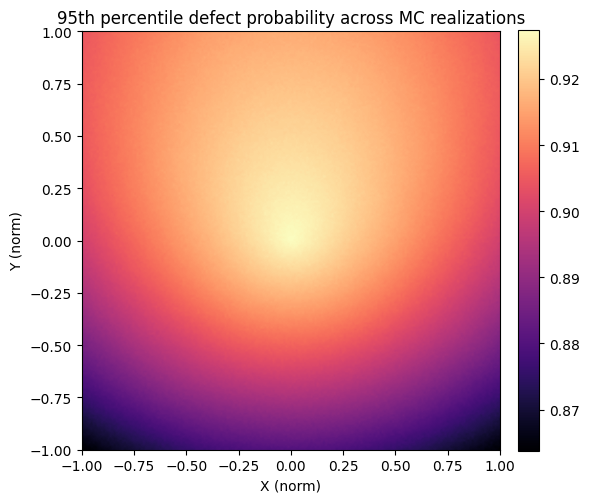

In [7]:
# --- Monte Carlo study to compute probabilistic failure boundaries under process variations ---
# We sample many process realizations of global CD and thickness and compute p_defect; then compute quantiles of p at each site
n_mc = 400  # moderate for speed; increase for more accuracy
mc_p = np.zeros((n_mc, n_sites))
rng_mc = np.random.default_rng(2025)

for i in range(n_mc):
    # draw a new realization of process variables (global shift, local smooth noise, thickness noise, hotspots)
    # use a reproducible inner RNG
    cd_i, th_i, hot_i, _ = generate_process_vars(rng_mc)

    # compute energy for this MC realization
    E_i = energy_from_params(true_params, coords[:,2], cd_i, th_i, hot_i)

    # compute defect probabilities with safe numerical handling
    p_i = defect_probability_from_energy(E_i, kT=kT)
    p_i = np.clip(p_i, 1e-12, 1-1e-12)  # avoid exact 0/1

    mc_p[i,:] = p_i

# compute 50th and 95th percentiles across MC samples at each site
p50 = np.percentile(mc_p, 50, axis=0)
p95 = np.percentile(mc_p, 95, axis=0)

# visualize the 95th percentile defect probability map
fig6, ax6, im6 = plot_wafer_map(p95, "95th percentile defect probability across MC realizations")
plt.tight_layout()
if save_outputs: fig6.savefig(os.path.join(out_dir, "mc_p95_map.png"), dpi=150)

# Save a summary CSV with MLE and MC results
summary_csv = os.path.join(out_dir, "wafer_site_data.csv")
df_out = df.copy()
df_out["p_mle"] = p_mle
df_out["p50_mc"] = p50
df_out["p95_mc"] = p95
df_out.to_csv(summary_csv, index=False)
print("\nSaved wafer site CSV to:", summary_csv)

# Save parameters and results JSON for reproducibility
meta = {
    "true_params": true_params,
    "mle_params": dict(zip(mle_param_names, mle_params.tolist())),
    "auc_mle": float(auc_mle),
    "auc_lr": float(auc_lr),
    "n_sites": int(n_sites),
    "grid_size": int(grid_size)
}
with open(os.path.join(out_dir, "results_summary.json"), "w") as f:
    json.dump(meta, f, indent=2)
print("Saved results summary to:", os.path.join(out_dir, "results_summary.json"))


## **Diagnostic Feature Dependence**

---

The purpose of diagnostic feature dependence plots is to **validate the physical fidelity** of the MLE-estimated energy landscape model and confirm that it captures the expected relationships between process variables and failure probability.

### 1. Observed vs. predicted relationships

Two primary process variables are investigated:

1. **Critical Dimension (CD)**

   * The energy landscape model explicitly includes both a **linear term** ($w_{\rm cd} \cdot \mathrm{cd}*i$) and a **quadratic term** ($w*{\rm quad} \cdot \mathrm{cd}_i^2$).
   * These terms allow for **non-linear dependence** of failure probability on CD, capturing phenomena such as over-etch or under-etch sensitivity.
   * Diagnostic plots compare the **observed binary failures** ($f_i \in {0,1}$) to the **MLE-predicted probabilities** ($p_i^{\rm MLE}$) as a function of CD.
   * Agreement between the scatter of actual failures and the predicted curve indicates that the MLE correctly recovers the non-linear CD dependence.

2. **Film Thickness (t)**

   * The energy model includes a linear term ($w_{\rm th} \cdot t_i$).
   * Failure probability is expected to vary approximately linearly with thickness.
   * Scatter plots of failures vs. thickness, overlaid with predicted MLE probabilities, allow verification of this linear trend.

### 2. Interpretation of diagnostic plots

* **Scatter of observed failures:** Shows the stochastic nature of sitewise outcomes even for a deterministic probability map.
* **Predicted probability curve:** Represents the MLE model’s continuous mapping from a process variable to expected failure probability.
* **Agreement between scatter and curve:** Confirms that the model captures both the **linear and quadratic contributions** of process variables and accurately predicts failure trends.

### 3. Practical considerations

* Sort sitewise values for smooth plotting of predicted curves.
* Use transparency (($\alpha<1$)) for observed failures to visualize overlapping points in high-density regions.
* Plot each process variable separately to isolate effects and avoid multicollinearity confusion.
* Saving the plots ensures reproducibility and supports documentation of model validation.

### 4. Summary

Diagnostic feature dependence plots provide **visual confirmation** that the MLE energy landscape model:

* Accurately captures **non-linear CD effects** (quadratic dependence).
* Captures **linear thickness effects**.
* Reflects **stochastic variability** in the observed binary outcomes.

This step ensures that the physical model structure is interpretable and consistent with observed wafer-level behavior.


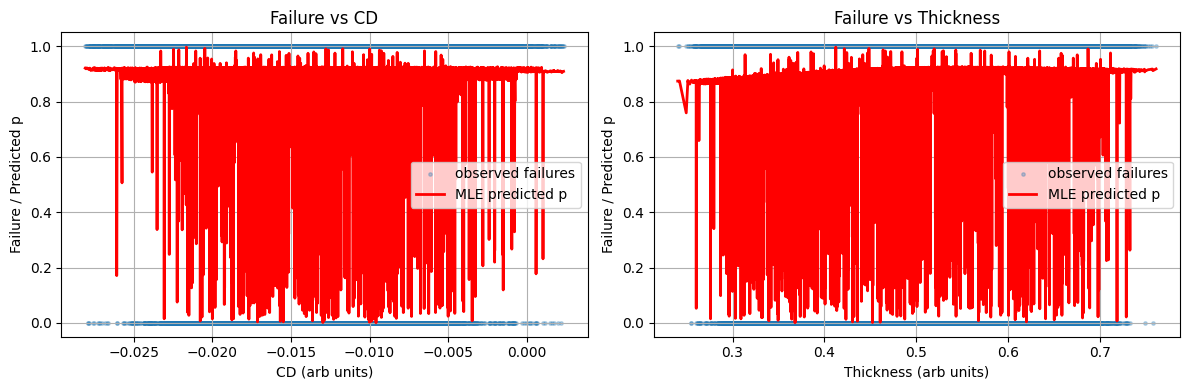

In [8]:
# --- Quick diagnostics plots for feature dependence ---
# Plot failure probability vs CD and thickness as scatter with predicted curves
fig7, ax7 = plt.subplots(1,2, figsize=(12,4))

# --- Critical Dimension (CD) ---
ax7[0].scatter(df["cd"].values, df["failure"].values, s=6, alpha=0.3, label="observed failures")
# sort CD for smooth predicted curve
cd_sorted_idx = np.argsort(df["cd"].values)
ax7[0].plot(df["cd"].values[cd_sorted_idx], p_mle[cd_sorted_idx], linewidth=2, color='r', label="MLE predicted p")
ax7[0].set_xlabel("CD (arb units)")
ax7[0].set_ylabel("Failure / Predicted p")
ax7[0].set_title("Failure vs CD")
ax7[0].legend()
ax7[0].grid(True)

# --- Thickness ---
th_sorted_idx = np.argsort(df["thickness"].values)
ax7[1].scatter(df["thickness"].values, df["failure"].values, s=6, alpha=0.3, label="observed failures")
ax7[1].plot(df["thickness"].values[th_sorted_idx], p_mle[th_sorted_idx], linewidth=2, color='r', label="MLE predicted p")
ax7[1].set_xlabel("Thickness (arb units)")
ax7[1].set_ylabel("Failure / Predicted p")
ax7[1].set_title("Failure vs Thickness")
ax7[1].legend()
ax7[1].grid(True)

plt.tight_layout()
# optionally save the figure
if save_outputs:
    fig7.savefig(os.path.join(out_dir, "feature_dependence.png"), dpi=150)


# **Conclusion**

---

## **Final Summary**

This notebook demonstrated a complete, physics-informed framework for modeling yield loss mechanisms in advanced semiconductor fabrication. By combining spatial wafer modeling, physically grounded process variables, and maximum-likelihood parameter estimation, we constructed an interpretable **Energy-Landscape Failure Model** capable of capturing both linear and nonlinear sensitivities—most notably the quadratic dependence on $\mathrm{CD}^2$.

The model parameters $w$ were directly learned from wafer-level failure data, enabling an end-to-end estimation of the underlying physical coefficients that govern defect formation. Beyond deterministic prediction, a comprehensive **Monte Carlo variability analysis** was implemented to propagate process fluctuations (global CD shift, local spatial noise, thickness gradient, random hotspots) through the energy model. This produced robust reliability envelopes, including **site-wise 95th percentile defect probabilities** ($p_{95}$), which identify spatial regions most vulnerable to worst-case process excursions.

Overall, the workflow presented here establishes a rigorous, quantitatively interpretable methodology that unifies:

1. **Physics-based modeling**
2. **Statistical inference (MLE)**
3. **Spatial wafer simulation**
4. **Monte Carlo uncertainty quantification**

Such a framework is directly applicable for **advanced process control, yield prediction, hotspot diagnosis**, and **design-for-manufacturing optimization** in leading-edge semiconductor nodes.


---



## **Future Work**

---

While the current model is powerful and fully functional, several extensions can further elevate its predictive accuracy and industrial applicability:

### **1. Incorporation of Additional Physics**

Future versions may integrate:

* Line-edge roughness (LER) variability
* Etch microloading effects
* Temperature-dependent film stress
* Lithography stochastic noise (photon shot noise, resist blur)

This would enable a more complete physical coverage of modern EUV and sub-7nm process steps.

### **2. Spatial Correlation Modeling**

Introducing Gaussian Processes or Markov Random Fields can capture long-range spatial coupling, enabling improved prediction of:

* wafer-level radial signatures
* edge roll-off effects
* cluster-type defect behavior

### **3. Bayesian Parameter Estimation**

A Bayesian extension of the energy model would allow:

* credible intervals on physical parameters
* hierarchical modeling across multiple wafers
* principled uncertainty quantification in predictions

### **4. Integration with Real Fab Data Systems**

Deploying the model in a fab environment alongside inline metrology (CD-SEM, ellipsometry, scatterometry, etc.) would support:

* real-time process monitoring
* predictive feedback control
* adaptive sampling strategies for metrology reduction

### **5. Deep Learning Hybridization**

A hybrid physics-ML architecture can fuse:

* interpretable energy-based physics terms
* non-linear corrections via neural networks

yielding a high-accuracy, physics-consistent predictor.

---


# **Recommended Extensions**

---

To progress this synthetic wafer study into a production-grade, research-level framework for high-volume manufacturing (HVM), the following extensions are recommended. Each item increases model fidelity, inference robustness, or operational relevance for yield engineering and process control.

* Use real fab metrology and inline test data (shot-level)
Replace synthetic draws with measured CD-SEM, scatterometry, ellipsometry, and inline electrical test data. Shot-level measurements enable direct calibration of model terms, reduce simulator bias, and expose real-world noise characteristics (instrument, sampling and censoring effects).

* Model spatial structure with Gaussian Processes (GPs)
Replace ad-hoc Fourier synthesis with explicit spatial priors (e.g., Matérn kernels) or GP latent fields. Estimating GP hyperparameters jointly with energy coefficients captures correlation length scales, anisotropy (directional dependence), and yields principled uncertainty propagation across the wafer.

* Adopt hierarchical Bayesian inference
Move from pointwise MLE to hierarchical Bayesian models (PyMC, NumPyro). Hierarchical structure enables pooling information across wafers/lots/tools, yields posterior distributions for the physical parameters, and naturally quantifies epistemic and aleatoric uncertainty for decision making.

* Physically calibrate the effective temperature scale ($kT$)
Fit or constrain $kT$ using independent device or process physics (thermal sensitivity, activation energies) or treat $kT$ as a hyperparameter in Bayesian inference. Proper calibration improves probability calibration and interpretability of energy coefficients.

* Rigorous validation: cross-wafer and cross-lot holdout
Use holdout wafers and lots for out-of-sample validation. Evaluate transferability (train on subset of tools/lots, test on others), and use metrics beyond AUC (calibration error, Brier score, cost-weighted decisions) for production readiness.

* Add equipment and layout covariates
Incorporate tool ID, reticle/mask coordinates, exposure dose maps, OPC residuals, and stepper/etch chamber covariates. These covariates explain systematic biases and allow targeted corrective actions (tool maintenance, recipe tuning).

* Hybrid physics–ML architectures
Combine the interpretable energy terms with flexible correction functions (e.g., small neural nets or Gaussian processes) to capture unmodeled nonlinearities while preserving interpretability of the main physics coefficients.

* Operationalization & monitoring
Integrate the model into fab dashboards for real-time risk scoring, implement thresholds for in-line interventions, and run continuous model recalibration with streaming metrology.

In [9]:
import os

# Define out_dir for this cell's execution, in case previous cells were not run
out_dir = "/kaggle/working/"

# Check if output directory exists. If not, and we expect files to be saved,
# this indicates prior cells might not have been run.
if not os.path.exists(out_dir):
    print("\nWarning: Output directory does not exist. Please ensure all preceding cells (especially those generating plots and data) have been executed.")
    print("If this is the first time running, please run all cells above this one to generate the outputs.")

# Print quick how-to and next steps -
print("\n--- Recommended Research-Grade Extensions for Study ---")
print("1) Replace synthetic data with measured metrology and inline test failures from fabs (shot-level data).")
print("2) Include spatial Gaussian Process (GP) prior / kernel to model smooth spatial variations explicitly.")
print("3) Use hierarchical Bayesian inference (e.g., with PyMC or NumPyro) to quantify parameter uncertainties.")
print("4) Calibrate effective kT using temperature/process scaling or use physical scaling from device models.")
print("5) Validate using cross-wafer and cross-lot holdout: train on some wafers/lots, validate on others.")
print("6) Add equipment / tool-level covariates, mask-level lithography patterns, OPC residuals, etc.")

# Provide a short checklist and file outputs
print("\nOutputs saved to:", out_dir)
# print only files that actually exist (helps for notebook runs where saving may be skipped)
outputs = [
    "true_p_defect_map.png",
    "simulated_failure_map.png",
    "mle_p_defect_map.png",
    "mc_p95_map.png",
    "wafer_site_data.csv",
    "results_summary.json"
]
for fname in outputs:
    path = os.path.join(out_dir, fname)
    if os.path.exists(path):
        print(" -", fname)
    else:
        print(" -", fname, "(not found)")

# Show a few images inline in the notebook (matplotlib already embedded)
# import matplotlib.pyplot as plt # Assuming plt is already imported in previous cells if needed for other plots
# plt.show()


--- Recommended Research-Grade Extensions for Study ---
1) Replace synthetic data with measured metrology and inline test failures from fabs (shot-level data).
2) Include spatial Gaussian Process (GP) prior / kernel to model smooth spatial variations explicitly.
3) Use hierarchical Bayesian inference (e.g., with PyMC or NumPyro) to quantify parameter uncertainties.
4) Calibrate effective kT using temperature/process scaling or use physical scaling from device models.
5) Validate using cross-wafer and cross-lot holdout: train on some wafers/lots, validate on others.
6) Add equipment / tool-level covariates, mask-level lithography patterns, OPC residuals, etc.

Outputs saved to: /kaggle/working/
 - true_p_defect_map.png
 - simulated_failure_map.png
 - mle_p_defect_map.png
 - mc_p95_map.png
 - wafer_site_data.csv
 - results_summary.json
